In [1]:
import numpy
import pandas

from matplotlib import pyplot
import seaborn

titanic = pandas.read_csv("../../conjuntos/titanic.csv")

titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [58]:
y = titanic["Survived"]

x1 = (titanic["Pclass"] == 1).astype(int)
x1 = x1.fillna(x1.median())
x2 = (titanic["Pclass"] == 2).astype(int)
x2 = x2.fillna(x2.median())
x3 = (titanic["Sex"] == "female").astype(int)
x3 = x3.fillna(x3.median())
x4 = (titanic["Age"] - titanic["Age"].mean()) / titanic["Age"].std()
x4 = x4.fillna(x4.median())
x5 = titanic["SibSp"] + titanic["Parch"]
x5 = x5.fillna(x5.median())
x6 = ~titanic["Cabin"].isna()
x6 = x6.fillna(x6.median())

## Influencia de las características sobre la respuesta

> x1 - Ser primera clase

<Axes: xlabel='Pclass', ylabel='Density'>

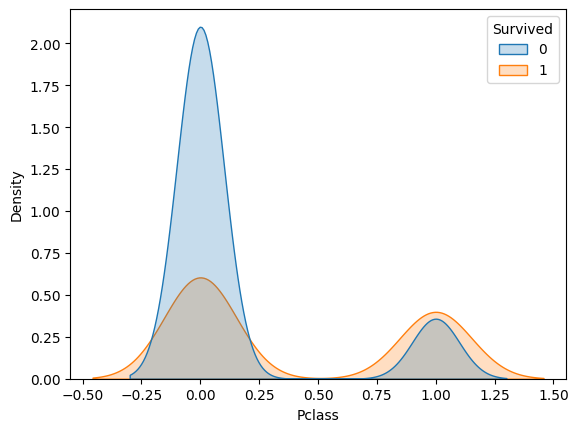

In [60]:
seaborn.kdeplot(x=x1, hue=y, fill=True)

Interpretación:

- *Sobreviven* - De las personas que sobrevivieron, aproximadamente un 40% era de primera clase y otro 60% era de otras clases
- *No sobreviven* - De las personas que no sobrevivieron, aproximadamente un 15% era de primera clase y otro 85% era de otras clases

In [61]:
print(f"Es primera clase: {x1.sum()} de {x1.size} ({100 * x1.sum() / x1.size:.1f}%)")
print(f"No es primera clase: {(1 - x1).sum()} de {(1 - x1).size} ({100 * (1 - x1).sum() / (1 - x1).size:.1f}%)")

print("-" * 60)

print(f"Sobreviven primera clase: {(x1 * y).sum()} de {y.size} ({100 * (x1 * y).sum() / y.size:.1f}%)")
print(f"No sobreviven primera clase: {(x1 * (1 - y)).sum()} de {(1 - y).size} ({100 * (x1 * (1 - y)).sum() / (1 - y).size:.1f}%)")

print("-" * 60)

filtro = y == 1
print(f"Sobreviven y son primera clase: {(x1[filtro] * y[filtro]).sum()} de {y[filtro].size} ({100 * (x1[filtro] * y[filtro]).sum() / y[filtro].size:.1f}%)")
filtro = y == 1
print(f"Sobreviven y no son primera clase: {((1 - x1[filtro]) * y[filtro]).sum()} de {y[filtro].size} ({100 * ((1 - x1[filtro]) * y[filtro]).sum() / y[filtro].size:.1f}%)")

filtro = y == 0
print(f"No sobreviven y son primera clase: {(x1[filtro] * (1 - y[filtro])).sum()} de {(1 - y[filtro]).size} ({100 * (x1[filtro] * (1 - y[filtro])).sum() / y[filtro].size:.1f}%)")
filtro = y == 0
print(f"No sobreviven y no son primera clase: {((1 - x1[filtro]) * (1 - y[filtro])).sum()} de {(1 - y[filtro]).size} ({100 * ((1 - x1[filtro]) * (1 - y[filtro])).sum() / y[filtro].size:.1f}%)")

print("-" * 60)

filtro = y == 1
a = (x1[filtro] * y[filtro]).sum() / y[filtro].size
filtro = y == 0
b = (x1[filtro] * (1 - y[filtro])).sum() / y[filtro].size
print(f"Chances de sobrevivir primera clase: {a / b:.2f}")
filtro = y == 1
a = y[filtro].sum()
filtro = y == 0
b = (1 - y[filtro]).sum()
print(f"Chances de sobrevivir global: {a / b:.2f}")

Es primera clase: 216 de 891 (24.2%)
No es primera clase: 675 de 891 (75.8%)
------------------------------------------------------------
Sobreviven primera clase: 136 de 891 (15.3%)
No sobreviven primera clase: 80 de 891 (9.0%)
------------------------------------------------------------
Sobreviven y son primera clase: 136 de 342 (39.8%)
Sobreviven y no son primera clase: 206 de 342 (60.2%)
No sobreviven y son primera clase: 80 de 549 (14.6%)
No sobreviven y no son primera clase: 469 de 549 (85.4%)
------------------------------------------------------------
Chances de sobrevivir primera clase: 2.73
Chances de sobrevivir global: 0.62


> x2 - Ser segunda clase

<Axes: xlabel='Pclass', ylabel='Density'>

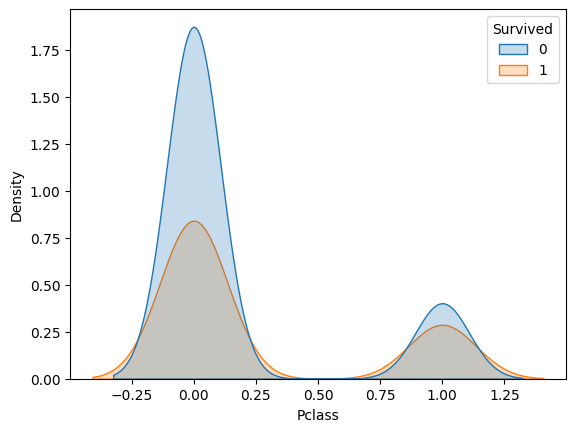

In [62]:
seaborn.kdeplot(x=x2, hue=y, fill=True)

Interpretación:

- *Sobreviven* - De las personas que sobrevivieron, aproximadamente un 25% era de segunda clase y otro 75% era de otras clases
- *No sobreviven* - De las personas que no sobrevivieron, aproximadamente un 20% era de segunda clase y otro 80% era de otras clases

In [63]:
print(f"Es segunda clase: {x2.sum()} de {x2.size} ({100 * x2.sum() / x2.size:.1f}%)")
print(f"No es segunda clase: {(1 - x2).sum()} de {(1 - x2).size} ({100 * (1 - x2).sum() / (1 - x2).size:.1f}%)")

print("-" * 60)

print(f"Sobreviven segunda clase: {(x2 * y).sum()} de {y.size} ({100 * (x2 * y).sum() / y.size:.1f}%)")
print(f"No sobreviven segunda clase: {(x2 * (1 - y)).sum()} de {(1 - y).size} ({100 * (x2 * (1 - y)).sum() / (1 - y).size:.1f}%)")

print("-" * 60)

filtro = y == 1
print(f"Sobreviven y son segunda clase: {(x2[filtro] * y[filtro]).sum()} de {y[filtro].size} ({100 * (x2[filtro] * y[filtro]).sum() / y[filtro].size:.1f}%)")
filtro = y == 1
print(f"Sobreviven y no son segunda clase: {((1 - x2[filtro]) * y[filtro]).sum()} de {y[filtro].size} ({100 * ((1 - x2[filtro]) * y[filtro]).sum() / y[filtro].size:.1f}%)")

filtro = y == 0
print(f"No sobreviven y son segunda clase: {(x2[filtro] * (1 - y[filtro])).sum()} de {(1 - y[filtro]).size} ({100 * (x2[filtro] * (1 - y[filtro])).sum() / y[filtro].size:.1f}%)")
filtro = y == 0
print(f"No sobreviven y no son segunda clase: {((1 - x2[filtro]) * (1 - y[filtro])).sum()} de {(1 - y[filtro]).size} ({100 * ((1 - x2[filtro]) * (1 - y[filtro])).sum() / y[filtro].size:.1f}%)")

print("-" * 60)

filtro = y == 1
a = (x2[filtro] * y[filtro]).sum() / y[filtro].size
filtro = y == 0
b = (x2[filtro] * (1 - y[filtro])).sum() / y[filtro].size
print(f"Chances de sobrevivir segunda clase: {a / b:.2f}")
filtro = y == 1
a = y[filtro].sum()
filtro = y == 0
b = (1 - y[filtro]).sum()
print(f"Chances de sobrevivir global: {a / b:.2f}")

Es segunda clase: 184 de 891 (20.7%)
No es segunda clase: 707 de 891 (79.3%)
------------------------------------------------------------
Sobreviven segunda clase: 87 de 891 (9.8%)
No sobreviven segunda clase: 97 de 891 (10.9%)
------------------------------------------------------------
Sobreviven y son segunda clase: 87 de 342 (25.4%)
Sobreviven y no son segunda clase: 255 de 342 (74.6%)
No sobreviven y son segunda clase: 97 de 549 (17.7%)
No sobreviven y no son segunda clase: 452 de 549 (82.3%)
------------------------------------------------------------
Chances de sobrevivir segunda clase: 1.44
Chances de sobrevivir global: 0.62


> (1 - x1) * (1 - x2) - Ser tercera clase (no ser primera clase y no ser segunda clase)

<Axes: xlabel='Pclass', ylabel='Density'>

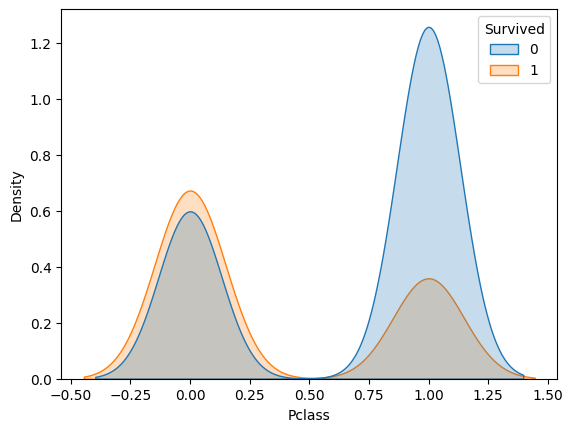

In [64]:
seaborn.kdeplot(x=((1 - x1) * (1 - x2)), hue=y, fill=True, warn_singular=False)

Interpretación:

- *Sobreviven* - De las personas que sobrevivieron, aproximadamente un 30% era de tercera clase y otro 70% era de otras clases
- *No sobreviven* - De las personas que no sobrevivieron, aproximadamente un 70% era de tercera clase y otro 30% era de otras clases

In [65]:
print(f"Es tercera clase: {((1 - x1) * (1 - x2)).sum()} de {((1 - x1) * (1 - x2)).size} ({100 * ((1 - x1) * (1 - x2)).sum() / ((1 - x1) * (1 - x2)).size:.1f}%)")
print(f"No es tercera clase: {(1 - ((1 - x1) * (1 - x2))).sum()} de {(1 - ((1 - x1) * (1 - x2))).size} ({100 * (1 - ((1 - x1) * (1 - x2))).sum() / (1 - ((1 - x1) * (1 - x2))).size:.1f}%)")

print("-" * 60)

print(f"Sobreviven tercera clase: {(((1 - x1) * (1 - x2)) * y).sum()} de {y.size} ({100 * (((1 - x1) * (1 - x2)) * y).sum() / y.size:.1f}%)")
print(f"No sobreviven tercera clase: {(((1 - x1) * (1 - x2)) * (1 - y)).sum()} de {(1 - y).size} ({100 * (((1 - x1) * (1 - x2)) * (1 - y)).sum() / (1 - y).size:.1f}%)")

print("-" * 60)

filtro = y == 1
print(f"Sobreviven y son tercera clase: {(((1 - x1) * (1 - x2))[filtro] * y[filtro]).sum()} de {y[filtro].size} ({100 * (((1 - x1) * (1 - x2))[filtro] * y[filtro]).sum() / y[filtro].size:.1f}%)")
filtro = y == 1
print(f"Sobreviven y no son tercera clase: {((1 - ((1 - x1) * (1 - x2))[filtro]) * y[filtro]).sum()} de {y[filtro].size} ({100 * ((1 - ((1 - x1) * (1 - x2))[filtro]) * y[filtro]).sum() / y[filtro].size:.1f}%)")

filtro = y == 0
print(f"No sobreviven y son tercera clase: {(((1 - x1) * (1 - x2))[filtro] * (1 - y[filtro])).sum()} de {(1 - y[filtro]).size} ({100 * (((1 - x1) * (1 - x2))[filtro] * (1 - y[filtro])).sum() / y[filtro].size:.1f}%)")
filtro = y == 0
print(f"No sobreviven y no son tercera clase: {((1 - ((1 - x1) * (1 - x2))[filtro]) * (1 - y[filtro])).sum()} de {(1 - y[filtro]).size} ({100 * ((1 - ((1 - x1) * (1 - x2))[filtro]) * (1 - y[filtro])).sum() / y[filtro].size:.1f}%)")

print("-" * 60)

filtro = y == 1
a = (((1 - x1) * (1 - x2))[filtro] * y[filtro]).sum() / y[filtro].size
filtro = y == 0
b = (((1 - x1) * (1 - x2))[filtro] * (1 - y[filtro])).sum() / y[filtro].size
print(f"Chances de sobrevivir tercera clase: {a / b:.2f}")
filtro = y == 1
a = y[filtro].sum()
filtro = y == 0
b = (1 - y[filtro]).sum()
print(f"Chances de sobrevivir global: {a / b:.2f}")

Es tercera clase: 491 de 891 (55.1%)
No es tercera clase: 400 de 891 (44.9%)
------------------------------------------------------------
Sobreviven tercera clase: 119 de 891 (13.4%)
No sobreviven tercera clase: 372 de 891 (41.8%)
------------------------------------------------------------
Sobreviven y son tercera clase: 119 de 342 (34.8%)
Sobreviven y no son tercera clase: 223 de 342 (65.2%)
No sobreviven y son tercera clase: 372 de 549 (67.8%)
No sobreviven y no son tercera clase: 177 de 549 (32.2%)
------------------------------------------------------------
Chances de sobrevivir tercera clase: 0.51
Chances de sobrevivir global: 0.62


In [66]:
1 / 0.62

1.6129032258064517

In [67]:
1 / 2.73

0.3663003663003663

In [68]:
1 / 1.44

0.6944444444444444

In [69]:
1 / 0.51

1.9607843137254901

Conclusión de la supervivencia de primera y segunda clase:

Las personas que eran de primera clase tenían casi tres veces de probabilidades de sobrevevivir, respecto a las que no sobrevivieron siendo de primera clase (2.71 chances)

Las personas que eran de segunda clase tenían casi 1.5 veces de probabilidades de sobrevevivir, respecto a las que no sobrevivieron siendo de segunda clase (1.44 chances)

Las personas que no eran de primera clase ni de segunda clase tenían la mitad de probabilidades de sobrevevivir, respecto a las que no sobrevivieron siendo de esta tercera clase (0.51 chances)

Esto sugiere que ser primera clase aumenta bastante la probabilidad de sobrevivir, segunda clase también aunque más moderado (2 / 3 sobreviven) y tercera clase tiene un efecto contrario reduciendo las oportunidades de sobrevivir, o visto al revés ($1 / 0.51 \approx 2$ veces chances de no sobrevivir)

Mientras que en las clases sociales altas la supervivencia es mayor a 2 de 3, en la tercera clase es al revés y solo sobrevive 1 de 3.

Podemos resumir la supervivencia de la primera, segunda y tercera clase como:

> Chances de supervivencia por clase social

Clase | Chances (Sobrevivir) | Inverso (No sobrevivir)
--- | :-: | :-:
Todas | 0.62 | **1.61**
Primera | **2.73** | 0.37
Segunda | **1.44** | 0.69
Tercera | 0.51 | **1.96**

**Nota:** Es más fácil interpretar los chances mayores a uno, porque dicen cuántas veces aumenta el porcentaje respecto al otro, si es menor a 1, es más difícil interpretar su valor, por ejemplo, 0.51 chances de sobrevivir, se entiende menos que 1.96 chances de no sobrevivir, ya que es más fácil pensar que por cada persona que sobrevive, hay 2 personas (1.96 personas) no sobreviven.

> x3 - Ser mujer

<Axes: xlabel='Sex', ylabel='Density'>

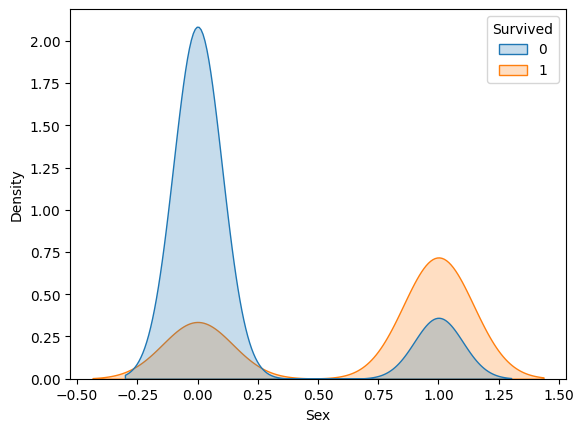

In [70]:
seaborn.kdeplot(x=x3, hue=y, fill=True)

Interpretación:

- *Sobreviven* - De las personas que sobrevivieron, aproximadamente un 70% eran mujeres y otro 30% eran hombres
- *No sobreviven* - De las personas que no sobrevivieron, aproximadamente un 15% eran mujeres y otro 85% eran hombres

In [71]:
print(f"Son mujeres: {x3.sum()} de {x3.size} ({100 * x3.sum() / x3.size:.1f}%)")
print(f"No son mujeres: {(1 - x3).sum()} de {(1 - x3).size} ({100 * (1 - x3).sum() / (1 - x3).size:.1f}%)")

print("-" * 60)

print(f"Sobreviven mujeres: {(x3 * y).sum()} de {y.size} ({100 * (x3 * y).sum() / y.size:.1f}%)")
print(f"No sobreviven mujeres: {(x3 * (1 - y)).sum()} de {(1 - y).size} ({100 * (x3 * (1 - y)).sum() / (1 - y).size:.1f}%)")

print("-" * 60)

filtro = y == 1
print(f"Sobreviven y son mujeres: {(x3[filtro] * y[filtro]).sum()} de {y[filtro].size} ({100 * (x3[filtro] * y[filtro]).sum() / y[filtro].size:.1f}%)")
filtro = y == 1
print(f"Sobreviven y no son mujeres: {((1 - x3[filtro]) * y[filtro]).sum()} de {y[filtro].size} ({100 * ((1 - x3[filtro]) * y[filtro]).sum() / y[filtro].size:.1f}%)")

filtro = y == 0
print(f"No sobreviven y son mujeres: {(x3[filtro] * (1 - y[filtro])).sum()} de {(1 - y[filtro]).size} ({100 * (x3[filtro] * (1 - y[filtro])).sum() / y[filtro].size:.1f}%)")
filtro = y == 0
print(f"No sobreviven y no son mujeres: {((1 - x3[filtro]) * (1 - y[filtro])).sum()} de {(1 - y[filtro]).size} ({100 * ((1 - x3[filtro]) * (1 - y[filtro])).sum() / y[filtro].size:.1f}%)")

print("-" * 60)

filtro = y == 1
a = (x3[filtro] * y[filtro]).sum() / y[filtro].size
filtro = y == 0
b = (x3[filtro] * (1 - y[filtro])).sum() / y[filtro].size
print(f"Chances de sobrevivir mujeres: {a / b:.2f}")
filtro = y == 1
a = y[filtro].sum()
filtro = y == 0
b = (1 - y[filtro]).sum()
print(f"Chances de sobrevivir global: {a / b:.2f}")

Son mujeres: 314 de 891 (35.2%)
No son mujeres: 577 de 891 (64.8%)
------------------------------------------------------------
Sobreviven mujeres: 233 de 891 (26.2%)
No sobreviven mujeres: 81 de 891 (9.1%)
------------------------------------------------------------
Sobreviven y son mujeres: 233 de 342 (68.1%)
Sobreviven y no son mujeres: 109 de 342 (31.9%)
No sobreviven y son mujeres: 81 de 549 (14.8%)
No sobreviven y no son mujeres: 468 de 549 (85.2%)
------------------------------------------------------------
Chances de sobrevivir mujeres: 4.62
Chances de sobrevivir global: 0.62


> (1 - x3) - No ser mujer (ser hombre)

<Axes: xlabel='Sex', ylabel='Density'>

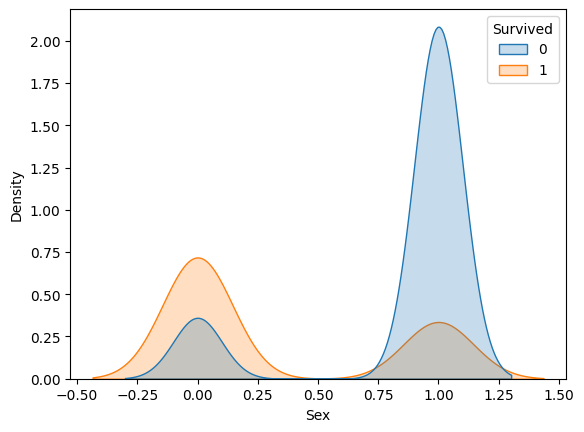

In [72]:
seaborn.kdeplot(x=(1 - x3), hue=y, fill=True)

Interpretación:

- *Sobreviven* - De las personas que sobrevivieron, aproximadamente un 30% eran mujeres y otro 70% eran hombres
- *No sobreviven* - De las personas que no sobrevivieron, aproximadamente un 85% eran mujeres y otro 15% eran hombres

In [73]:
print(f"Son hombres: {(1 - x3).sum()} de {(1 - x3).size} ({100 * (1 - x3).sum() / (1 - x3).size:.1f}%)")
print(f"No son hombres: {(1 - (1 - x3)).sum()} de {(1 - (1 - x3)).size} ({100 * (1 - (1 - x3)).sum() / (1 - (1 - x3)).size:.1f}%)")

print("-" * 60)

print(f"Sobreviven hombres: {((1 - x3) * y).sum()} de {y.size} ({100 * ((1 - x3) * y).sum() / y.size:.1f}%)")
print(f"No sobreviven hombres: {((1 - x3) * (1 - y)).sum()} de {(1 - y).size} ({100 * ((1 - x3) * (1 - y)).sum() / (1 - y).size:.1f}%)")

print("-" * 60)

filtro = y == 1
print(f"Sobreviven y son hombres: {((1 - x3)[filtro] * y[filtro]).sum()} de {y[filtro].size} ({100 * ((1 - x3)[filtro] * y[filtro]).sum() / y[filtro].size:.1f}%)")
filtro = y == 1
print(f"Sobreviven y no son hombres: {((1 - (1 - x3)[filtro]) * y[filtro]).sum()} de {y[filtro].size} ({100 * ((1 - (1 - x3)[filtro]) * y[filtro]).sum() / y[filtro].size:.1f}%)")

filtro = y == 0
print(f"No sobreviven y son hombres: {((1 - x3)[filtro] * (1 - y[filtro])).sum()} de {(1 - y[filtro]).size} ({100 * ((1 - x3)[filtro] * (1 - y[filtro])).sum() / y[filtro].size:.1f}%)")
filtro = y == 0
print(f"No sobreviven y no son hombres: {((1 - (1 - x3)[filtro]) * (1 - y[filtro])).sum()} de {(1 - y[filtro]).size} ({100 * ((1 - (1 - x3)[filtro]) * (1 - y[filtro])).sum() / y[filtro].size:.1f}%)")

print("-" * 60)

filtro = y == 1
a = ((1 - x3)[filtro] * y[filtro]).sum() / y[filtro].size
filtro = y == 0
b = ((1 - x3)[filtro] * (1 - y[filtro])).sum() / y[filtro].size
print(f"Chances de sobrevivir hombres: {a / b:.2f}")
filtro = y == 1
a = y[filtro].sum()
filtro = y == 0
b = (1 - y[filtro]).sum()
print(f"Chances de sobrevivir global: {a / b:.2f}")

Son hombres: 577 de 891 (64.8%)
No son hombres: 314 de 891 (35.2%)
------------------------------------------------------------
Sobreviven hombres: 109 de 891 (12.2%)
No sobreviven hombres: 468 de 891 (52.5%)
------------------------------------------------------------
Sobreviven y son hombres: 109 de 342 (31.9%)
Sobreviven y no son hombres: 233 de 342 (68.1%)
No sobreviven y son hombres: 468 de 549 (85.2%)
No sobreviven y no son hombres: 81 de 549 (14.8%)
------------------------------------------------------------
Chances de sobrevivir hombres: 0.37
Chances de sobrevivir global: 0.62


In [74]:
1 / 0.62

1.6129032258064517

In [75]:
1 / 4.62

0.21645021645021645

In [76]:
1 / 0.37

2.7027027027027026

Conclusión de la supervivencia de mujeres y hombres:

Las personas que eran mujeres tenían más de 4.5 veces de probabilidades de sobrevevivir, respecto a las que no sobrevivieron siendo mujeres (4.62 chances)

Las personas que eran hombres tenían más de 2.5 veces de probabilidades de no sobrevevivir, respecto a las que sobrevivieron siendo hombres (0.37 chances directos o 2.70 chances inversos)

Esto sugiere que ser mujer aumenta demasiado la supervivencia, mientras que ser hombre la disminuye.

Mientras que en mujeres la supervivencia es mayor a 9 de 11, en hombres es al revés y solo sobreviven 2 de 7.

Podemos resumir la supervivencia de mujeres y hombres:

> Chances de supervivencia por sexo

Clase | Chances (Sobrevivir) | Inverso (No sobrevivir)
--- | :-: | :-:
Todas | 0.62 | **1.61**
Mujeres | **4.62** | 0.22
Hombres | 0.37 | **2.70**

> x4 - Edad

<Axes: xlabel='Age', ylabel='Density'>

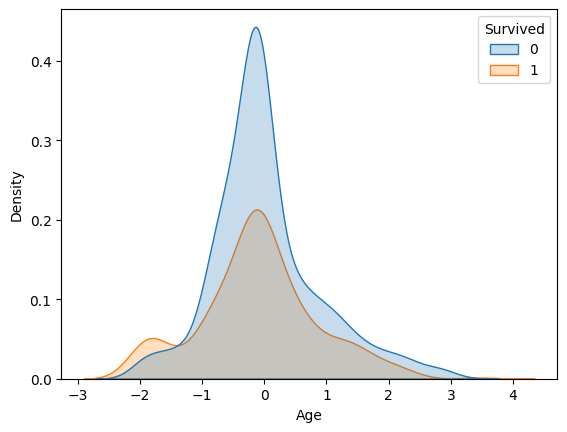

In [77]:
seaborn.kdeplot(x=x4, hue=y, fill=True)

Interpretación:

- *Sobreviven* - De las personas que sobrevivieron, se observa que la supervivencia aumenta en edades muy pequeñas
- *No sobreviven* - De las personas que no sobrevivieron, se observa que la no supervivencia aumenta en edades muy altas

In [109]:
print(f"Edad media: {titanic['Age'].mean():.2f} ({titanic['Age'].std():.2f})")

for sigma in range(1, 4):
    arriba = (x4 >= (sigma - 1)) & (x4 <= sigma)
    abajo = (x4 >= -sigma) & (x4 <= -(sigma - 1))

    sobrevive_arriba = y[arriba].sum()
    no_sobrevive_arriba = (1 - y[arriba]).sum()
    
    sobrevive_abajo = y[abajo].sum()
    no_sobrevive_abajo = (1 - y[abajo]).sum()

    print(f"Sigma: {sigma}")
    print("=" * 40)
    print(f"Chances sobrevive abajo: {sobrevive_abajo} a {no_sobrevive_abajo} ({sobrevive_abajo / no_sobrevive_abajo:.2f})")
    print(f"Chances no sobrevive abajo: {no_sobrevive_abajo} a {sobrevive_abajo} ({no_sobrevive_abajo / sobrevive_abajo:.2f})")
    print("-" * 40)
    print(f"Chances sobrevive arriba: {sobrevive_arriba} a {no_sobrevive_arriba} ({sobrevive_arriba / no_sobrevive_arriba:.2f})")
    print(f"Chances no sobrevive arriba: {no_sobrevive_arriba} a {sobrevive_arriba} ({no_sobrevive_arriba / sobrevive_arriba:.2f})")
    print()

Edad media: 29.70 (14.53)
Sigma: 1
Chances sobrevive abajo: 159 a 319 (0.50)
Chances no sobrevive abajo: 319 a 159 (2.01)
----------------------------------------
Chances sobrevive arriba: 91 a 124 (0.73)
Chances no sobrevive arriba: 124 a 91 (1.36)

Sigma: 2
Chances sobrevive abajo: 48 a 34 (1.41)
Chances no sobrevive abajo: 34 a 48 (0.71)
----------------------------------------
Chances sobrevive arriba: 36 a 51 (0.71)
Chances no sobrevive arriba: 51 a 36 (1.42)

Sigma: 3
Chances sobrevive abajo: 1 a 0 (inf)
Chances no sobrevive abajo: 0 a 1 (0.00)
----------------------------------------
Chances sobrevive arriba: 6 a 20 (0.30)
Chances no sobrevive arriba: 20 a 6 (3.33)



/var/folders/zr/py0pd6bs6gnfzg9ljbgr9v0c0000gn/T/ipykernel_21228/3344217117.py:15: RuntimeWarning: divide by zero encountered in scalar divide
  print(f"Chances sobrevive abajo: {sobrevive_abajo} a {no_sobrevive_abajo} ({sobrevive_abajo / no_sobrevive_abajo:.2f})")


In [101]:
mu = titanic["Age"].mean()
sigma = titanic["Age"].std()

for i in range(1, 4):
    l, r = mu - (4 - i) * sigma, mu - (4 - i - 1) * sigma
    print(f"De {l:.1f} a {r:.1f}")

for i in range(1, 4):
    l, r = mu + (i - 1) * sigma, mu + i * sigma
    print(f"De {l:.1f} a {r:.1f}")

De -13.9 a 0.6
De 0.6 a 15.2
De 15.2 a 29.7
De 29.7 a 44.2
De 44.2 a 58.8
De 58.8 a 73.3


> Chances de supervivencia por edad ($\mu \approx 29.7$, $\sigma \approx 14.5$)

Sigma | Chances Abajo (Sobrevive / No sobrevive) | Chances Arriba  (Sobrevive / No sobrevive)
:-: | :-: | :-:
1 | 0.50 / **2.01** (C) | 0.73 / **1.36** (D)
2 | **1.41** / 0.71 (B) | 0.71 / **1.42** (E)
3 | **$\infty$** / 0.00 (A) | 0.30 / **3.33** (F)

* **Grupo A** - De -13.9 a 0.6
* **Grupo B** - De 0.6 a 15.2
* **Grupo C** - De 15.2 a 29.7
* **Grupo D** - De 29.7 a 44.2
* **Grupo E** - De 44.2 a 58.8
* **Grupo F** - De 58.8 a 73.3

Podemos concluir que la mayor supervivencia se da en los menores a 15 años, mientras que grupos como de 15 a 29 años y de 59 a 73 años aumenta la no supervivencia (por cada uno que sobrevive más de 2 no lo hacen).

> x5 - Familiares

<Axes: xlabel='None', ylabel='Density'>

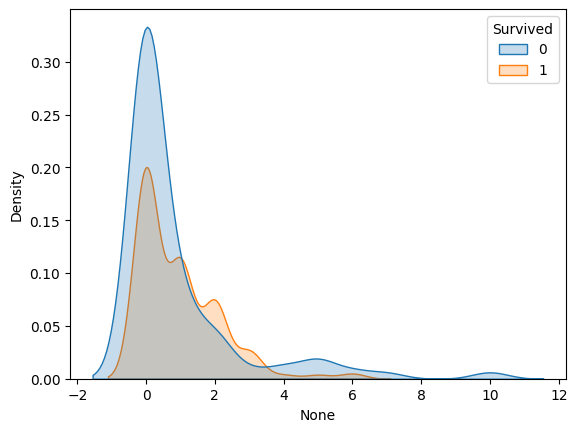

In [119]:
seaborn.kdeplot(x=x5, hue=y, fill=True)

Interpretación:

- *Sobreviven* - De las personas que sobrevivieron, se observa que la supervivencia aumenta de 2 a 3 familiares
- *No sobreviven* - De las personas que no sobrevivieron, se observa que la no supervivencia aumenta en menos de 1 familiar o más de 4 

In [126]:
for familiares in sorted(x5.unique()):
    filtro = x5 == familiares
    sobrevive = y[filtro].sum()
    no_sobrevive = (1 - y[filtro]).sum()

    print(f"Familiares: {familiares}")
    print("=" * 40)
    print(f"Chances sobrevive: {sobrevive} a {no_sobrevive} ({sobrevive / no_sobrevive:.2f})")
    print(f"Chances no sobrevive: {no_sobrevive} a {sobrevive} ({no_sobrevive / sobrevive:.2f})")
    print()

Familiares: 0
Chances sobrevive: 163 a 374 (0.44)
Chances no sobrevive: 374 a 163 (2.29)

Familiares: 1
Chances sobrevive: 89 a 72 (1.24)
Chances no sobrevive: 72 a 89 (0.81)

Familiares: 2
Chances sobrevive: 59 a 43 (1.37)
Chances no sobrevive: 43 a 59 (0.73)

Familiares: 3
Chances sobrevive: 21 a 8 (2.62)
Chances no sobrevive: 8 a 21 (0.38)

Familiares: 4
Chances sobrevive: 3 a 12 (0.25)
Chances no sobrevive: 12 a 3 (4.00)

Familiares: 5
Chances sobrevive: 3 a 19 (0.16)
Chances no sobrevive: 19 a 3 (6.33)

Familiares: 6
Chances sobrevive: 4 a 8 (0.50)
Chances no sobrevive: 8 a 4 (2.00)

Familiares: 7
Chances sobrevive: 0 a 6 (0.00)
Chances no sobrevive: 6 a 0 (inf)

Familiares: 10
Chances sobrevive: 0 a 7 (0.00)
Chances no sobrevive: 7 a 0 (inf)



/var/folders/zr/py0pd6bs6gnfzg9ljbgr9v0c0000gn/T/ipykernel_21228/2488152672.py:9: RuntimeWarning: divide by zero encountered in scalar divide
  print(f"Chances no sobrevive: {no_sobrevive} a {sobrevive} ({no_sobrevive / sobrevive:.2f})")
/var/folders/zr/py0pd6bs6gnfzg9ljbgr9v0c0000gn/T/ipykernel_21228/2488152672.py:9: RuntimeWarning: divide by zero encountered in scalar divide
  print(f"Chances no sobrevive: {no_sobrevive} a {sobrevive} ({no_sobrevive / sobrevive:.2f})")


In [132]:
int(y[y == 1].sum()), y.size, y.size - int(y[y == 1].sum())

(342, 891, 549)

> Chances de supervivencia por cantidad de familiares

Familiares | Chances (Sobrevive / No sobrevive) | Soporte
:-: | :-: | :-:
Global | 0.62 / **1.61** | 352:**549**
0 | 0.44 / **2.29** | 163:**374**
1 | **1.24** / 0.81 | **89**:72
2 | **1.37** / 0.73 | **59**:43
3 | **2.62** / 0.38 | **21**:8
4 | 0.25 / **4.00** | 3:**12**
5 | 0.16 / **6.33** | 3:**19**
6 | 0.50 / **2.00** | 4:**8**
7 | 0.00 / **$\infty$** | 0:**6**
10 | 0.00 / **$\infty$** | 0:**7**

Podemos concluir que la mayor supervivencia aumenta en personas que viajan con 1, 2 o 3 familiares, mientras que los demás grupos tienen más de 2 chances de no sobrevivir.

> x6 - Con cabina

<Axes: xlabel='Cabin', ylabel='Density'>

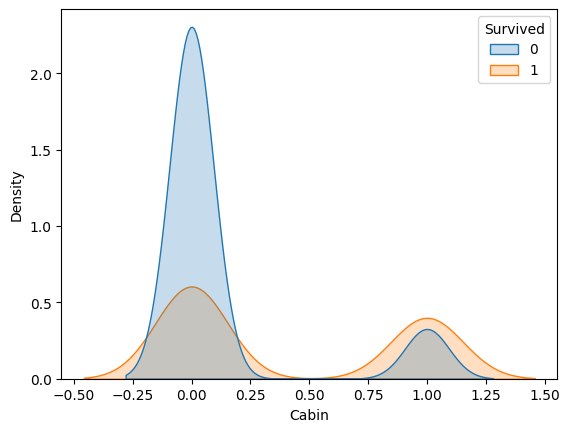

In [111]:
seaborn.kdeplot(x=x6, hue=y, fill=True)

Interpretación:

- *Sobreviven* - De las personas que sobrevivieron, aproximadamente un 45% tenía cabina y otro 55% no
- *No sobreviven* - De las personas que no sobrevivieron, aproximadamente un 25% tenía cabina y otro 75% no

In [113]:
print(f"Con cabina: {x6.sum()} de {x6.size} ({100 * x6.sum() / x6.size:.1f}%)")
print(f"Sin cabina: {(1 - x6).sum()} de {(1 - x6).size} ({100 * (1 - x6).sum() / (1 - x6).size:.1f}%)")

print("-" * 60)

print(f"Sobreviven con cabina: {(x6 * y).sum()} de {y.size} ({100 * (x6 * y).sum() / y.size:.1f}%)")
print(f"No sobreviven con cabina: {(x6 * (1 - y)).sum()} de {(1 - y).size} ({100 * (x6 * (1 - y)).sum() / (1 - y).size:.1f}%)")

print("-" * 60)

filtro = y == 1
print(f"Sobreviven y con cabina: {(x6[filtro] * y[filtro]).sum()} de {y[filtro].size} ({100 * (x6[filtro] * y[filtro]).sum() / y[filtro].size:.1f}%)")
filtro = y == 1
print(f"Sobreviven y sin cabina: {((1 - x6[filtro]) * y[filtro]).sum()} de {y[filtro].size} ({100 * ((1 - x6[filtro]) * y[filtro]).sum() / y[filtro].size:.1f}%)")

filtro = y == 0
print(f"No sobreviven y con cabina: {(x6[filtro] * (1 - y[filtro])).sum()} de {(1 - y[filtro]).size} ({100 * (x6[filtro] * (1 - y[filtro])).sum() / y[filtro].size:.1f}%)")
filtro = y == 0
print(f"No sobreviven y sin cabina: {((1 - x6[filtro]) * (1 - y[filtro])).sum()} de {(1 - y[filtro]).size} ({100 * ((1 - x6[filtro]) * (1 - y[filtro])).sum() / y[filtro].size:.1f}%)")

print("-" * 60)

filtro = y == 1
a = (x6[filtro] * y[filtro]).sum() / y[filtro].size
filtro = y == 0
b = (x6[filtro] * (1 - y[filtro])).sum() / y[filtro].size
print(f"Chances de sobrevivir con cabina: {a / b:.2f}")
filtro = y == 1
a = y[filtro].sum()
filtro = y == 0
b = (1 - y[filtro]).sum()
print(f"Chances de sobrevivir global: {a / b:.2f}")

Con cabina: 204 de 891 (22.9%)
Sin cabina: 687 de 891 (77.1%)
------------------------------------------------------------
Sobreviven con cabina: 136 de 891 (15.3%)
No sobreviven con cabina: 68 de 891 (7.6%)
------------------------------------------------------------
Sobreviven y con cabina: 136 de 342 (39.8%)
Sobreviven y sin cabina: 206 de 342 (60.2%)
No sobreviven y con cabina: 68 de 549 (12.4%)
No sobreviven y sin cabina: 481 de 549 (87.6%)
------------------------------------------------------------
Chances de sobrevivir con cabina: 3.21
Chances de sobrevivir global: 0.62


> (1 - x6) - Sin cabina

<Axes: xlabel='Cabin', ylabel='Density'>

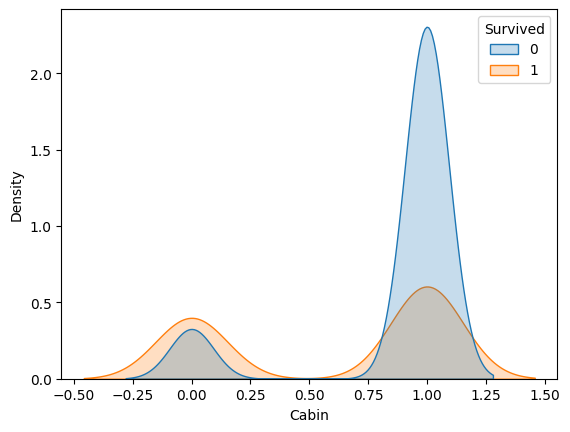

In [114]:
seaborn.kdeplot(x=(1 - x6), hue=y, fill=True)

Interpretación:

- *Sobreviven* - De las personas que sobrevivieron, aproximadamente un 55% no tenía cabina y otro 45% si
- *No sobreviven* - De las personas que no sobrevivieron, aproximadamente un 75% no tenía cabina y otro 25% si

In [116]:
print(f"Sin cabina: {(1 - x6).sum()} de {(1 - x6).size} ({100 * (1 - x6).sum() / (1 - x6).size:.1f}%)")
print(f"Con cabina: {(1 - (1 - x6)).sum()} de {(1 - (1 - x6)).size} ({100 * (1 - (1 - x6)).sum() / (1 - (1 - x6)).size:.1f}%)")

print("-" * 60)

print(f"Sobreviven sin cabina: {((1 - x6) * y).sum()} de {y.size} ({100 * ((1 - x6) * y).sum() / y.size:.1f}%)")
print(f"No sobreviven sin cabina: {((1 - x6) * (1 - y)).sum()} de {(1 - y).size} ({100 * ((1 - x6) * (1 - y)).sum() / (1 - y).size:.1f}%)")

print("-" * 60)

filtro = y == 1
print(f"Sobreviven y sin cabina: {((1 - x6)[filtro] * y[filtro]).sum()} de {y[filtro].size} ({100 * ((1 - x6)[filtro] * y[filtro]).sum() / y[filtro].size:.1f}%)")
filtro = y == 1
print(f"Sobreviven y con cabina: {((1 - (1 - x6)[filtro]) * y[filtro]).sum()} de {y[filtro].size} ({100 * ((1 - (1 - x6)[filtro]) * y[filtro]).sum() / y[filtro].size:.1f}%)")

filtro = y == 0
print(f"No sobreviven y sin cabina: {((1 - x6)[filtro] * (1 - y[filtro])).sum()} de {(1 - y[filtro]).size} ({100 * ((1 - x6)[filtro] * (1 - y[filtro])).sum() / y[filtro].size:.1f}%)")
filtro = y == 0
print(f"No sobreviven y con cabina: {((1 - (1 - x6)[filtro]) * (1 - y[filtro])).sum()} de {(1 - y[filtro]).size} ({100 * ((1 - (1 - x6)[filtro]) * (1 - y[filtro])).sum() / y[filtro].size:.1f}%)")

print("-" * 60)

filtro = y == 1
a = ((1 - x6)[filtro] * y[filtro]).sum() / y[filtro].size
filtro = y == 0
b = ((1 - x6)[filtro] * (1 - y[filtro])).sum() / y[filtro].size
print(f"Chances de sobrevivir sin cabina: {a / b:.2f}")
filtro = y == 1
a = y[filtro].sum()
filtro = y == 0
b = (1 - y[filtro]).sum()
print(f"Chances de sobrevivir global: {a / b:.2f}")

Sin cabina: 687 de 891 (77.1%)
Con cabina: 204 de 891 (22.9%)
------------------------------------------------------------
Sobreviven sin cabina: 206 de 891 (23.1%)
No sobreviven sin cabina: 481 de 891 (54.0%)
------------------------------------------------------------
Sobreviven y sin cabina: 206 de 342 (60.2%)
Sobreviven y con cabina: 136 de 342 (39.8%)
No sobreviven y sin cabina: 481 de 549 (87.6%)
No sobreviven y con cabina: 68 de 549 (12.4%)
------------------------------------------------------------
Chances de sobrevivir sin cabina: 0.69
Chances de sobrevivir global: 0.62


In [ ]:
1 / 0.62

1.6129032258064517

In [117]:
1 / 3.21

0.3115264797507788

In [118]:
1 / 0.69

1.4492753623188408

Conclusión de la supervivencia por cabina:

Las personas que contaban con cabina tenían más de 3 veces de probabilidades de sobrevevivir, respecto a las que no sobrevivieron teniendo cabina (4.62 chances)

Las personas que no contaban con cabina tenían cerca de 1.5 veces de probabilidades de no sobrevevivir, respecto a las que sobrevivieron y no tenían cabina (0.69 chances directos o 1.45 chances inversos)

Esto sugiere que tener cabina aumentó los chances de sobrevivir y el no tener cabina se aumentan los chances de no sobrevivir.

Mientras que con cabina la supervivencia es mayor 3 de 4, y sin cabina es al revés y solo sobreviven poco más de 2 de 5.

Podemos resumir la supervivencia de mujeres y hombres:

> Chances de supervivencia por sexo

Clase | Chances (Sobrevivir) | Inverso (No sobrevivir)
--- | :-: | :-:
Todas | 0.62 | **1.61**
Con cabina | **3.21** | 0.31
Sin cabina | 0.69 | **1.45**